In [52]:
import pandas as pd
from pandas import NamedAgg
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

In [53]:
df = pd.read_csv("Weather.csv")

In [54]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## Analyze Data Completeness by Country

In [55]:
print("Total countries:", df['country'].nunique())
print("Total records:", len(df))

country_counts = df['country'].value_counts()

print(country_counts.head(10))

selected_country = country_counts.idxmax()

print("\nSelected country (most records):", selected_country)


Total countries: 211
Total records: 124136
country
Bulgaria      1464
Indonesia     1277
Sudan         1274
Thailand      1273
Turkey        1273
Bolivia       1267
Iran          1253
Belgium       1216
Madagascar    1096
Vietnam       1072
Name: count, dtype: int64

Selected country (most records): Bulgaria


## Filter Data for Bulgaria and Prepare Features

In [56]:
# keep only selected country
df = df[df['country'] == selected_country].copy()

print(f"Using country: {selected_country} | records: {len(df)}")

# features + target
features = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "cloud",
    "wind_degree"
]

df['will_rain'] = (df['precip_mm'] > 0).astype(int)

X = df[features]
y = df['will_rain']

print("Target distribution:\n", y.value_counts())

Using country: Bulgaria | records: 1464
Target distribution:
 will_rain
0    1123
1     341
Name: count, dtype: int64


## Data Cleaning

In [57]:
# Drop unnecessary columns - keep only features and target
target_col = 'will_rain'
df = df[features + [target_col]] 
print(f"Dataset shape after dropping unnecessary columns: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Dataset shape after dropping unnecessary columns: (1464, 6)
Remaining columns: ['temperature_celsius', 'humidity', 'wind_kph', 'cloud', 'wind_degree', 'will_rain']


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 25 to 124116
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature_celsius  1464 non-null   float64
 1   humidity             1464 non-null   int64  
 2   wind_kph             1464 non-null   float64
 3   cloud                1464 non-null   int64  
 4   wind_degree          1464 non-null   int64  
 5   will_rain            1464 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 80.1 KB


## Data Processing & Feature Engineering
we're deriving the target variable from the precip_mm column:
will_rain = 1  (if precip_mm > 0)
will_rain = 0  (if precip_mm = 0)

In [59]:
# Prepare X (features) and y (target) from cleaned data
X = df[features]
y = df[target_col]

## Prepare Features and Target Variable

In [60]:
print(f"Features shape: {X.shape}\nTarget shape: {y.shape}\n")
print("Target distribution:\n", y.value_counts())

Features shape: (1464, 5)
Target shape: (1464,)

Target distribution:
 will_rain
0    1123
1     341
Name: count, dtype: int64


In [61]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 1171
Testing set size: 293


In [62]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"Training features mean: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Training features std: {X_train_scaled.std(axis=0).mean():.4f}")


Features scaled successfully!
Training features mean: 0.0000
Training features std: 1.0000


## Train the Naive Bayes Model

In [63]:
# Train Naive Bayes classifier
model = GaussianNB()
model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [64]:
# Make predictions on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

Model Accuracy: 0.7884 (78.84%)

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.91      0.81      0.85       225
        Rain       0.53      0.72      0.61        68

    accuracy                           0.79       293
   macro avg       0.72      0.76      0.73       293
weighted avg       0.82      0.79      0.80       293



In [66]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")


Confusion Matrix:
[[182  43]
 [ 19  49]]

True Negatives: 182
False Positives: 43
False Negatives: 19
True Positives: 49


## Model Visualizations

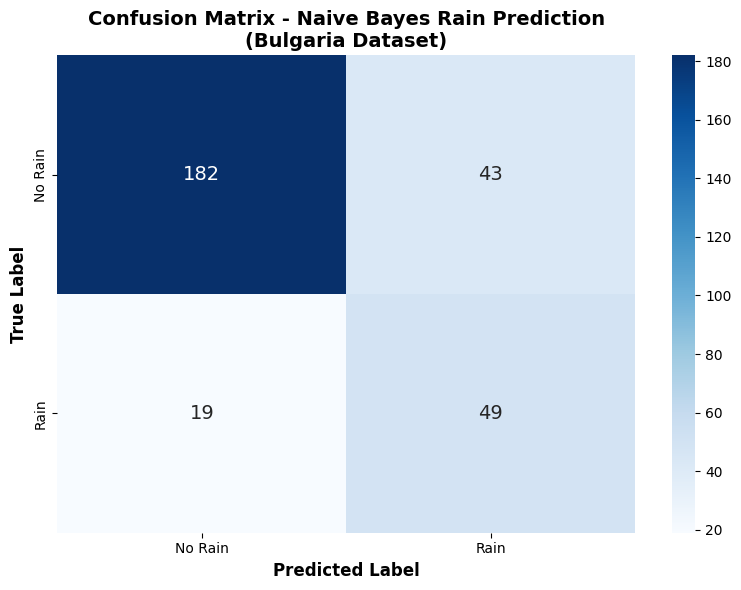


Confusion Matrix Visualization saved!


In [67]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'],
            annot_kws={'fontsize': 14},
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Naive Bayes Rain Prediction\n(Bulgaria Dataset)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Visualization saved!")

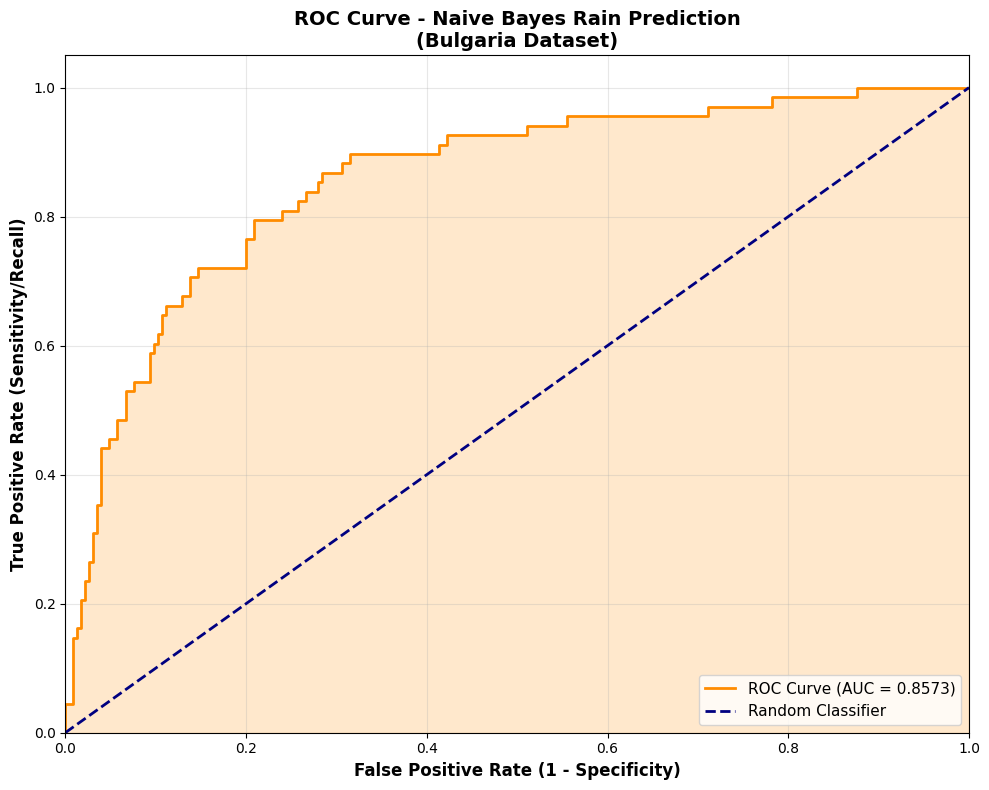


ROC Curve Analysis:
AUC Score: 0.8573


In [68]:
# Calculate ROC Curve and AUC Score
# Get probability of positive class
y_pred_proba_pos = y_pred_proba[:, 1]

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_pos)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Naive Bayes Rain Prediction\n(Bulgaria Dataset)', 
             fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC Curve Analysis:")
print(f"AUC Score: {roc_auc:.4f}")

## Summary of Model Performance

In [69]:
# Extract detailed metrics from classification report
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

# Create performance summary
print("\n" + "="*70)
print("NAIVE BAYES RAIN PREDICTION MODEL - PERFORMANCE SUMMARY")
print("="*70)
print(f"\nDataset: Bulgaria")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Number of Features: {len(features)}")
print(f"Features Used: {', '.join(features)}")

print(f"\n{'OVERALL METRICS':-^70}")
print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"AUC Score:   {roc_auc:.4f}")

print(f"\n{'PER-CLASS METRICS':-^70}")
print(f"{'Class':<15} {'Precision':<15} {'Recall':<15} {'F1-Score':<15} {'Support':<10}")
print("-" * 70)
print(f"{'No Rain':<15} {precision[0]:<15.4f} {recall[0]:<15.4f} {f1[0]:<15.4f} {int(support[0]):<10}")
print(f"{'Rain':<15} {precision[1]:<15.4f} {recall[1]:<15.4f} {f1[1]:<15.4f} {int(support[1]):<10}")

print(f"\n{'CONFUSION MATRIX BREAKDOWN':-^70}")
print(f"True Negatives (Correctly predicted No Rain):  {cm[0][0]}")
print(f"False Positives (Incorrectly predicted Rain):   {cm[0][1]}")
print(f"False Negatives (Missed Rain):                  {cm[1][0]}")
print(f"True Positives (Correctly predicted Rain):      {cm[1][1]}")

print(f"\n{'DERIVED METRICS':-^70}")
specificity = cm[0][0] / (cm[0][0] + cm[0][1])
sensitivity = cm[1][1] / (cm[1][1] + cm[1][0])
print(f"Sensitivity/Recall:  {sensitivity:.4f}")
print(f"Specificity:         {specificity:.4f}")
print(f"Precision (Rain):    {precision[1]:.4f}")

print("\n" + "="*70)


NAIVE BAYES RAIN PREDICTION MODEL - PERFORMANCE SUMMARY

Dataset: Bulgaria
Training Samples: 1171
Testing Samples: 293
Number of Features: 5
Features Used: temperature_celsius, humidity, wind_kph, cloud, wind_degree

---------------------------OVERALL METRICS----------------------------
Accuracy:    0.7884 (78.84%)
AUC Score:   0.8573

--------------------------PER-CLASS METRICS---------------------------
Class           Precision       Recall          F1-Score        Support   
----------------------------------------------------------------------
No Rain         0.9055          0.8089          0.8545          225       
Rain            0.5326          0.7206          0.6125          68        

----------------------CONFUSION MATRIX BREAKDOWN----------------------
True Negatives (Correctly predicted No Rain):  182
False Positives (Incorrectly predicted Rain):   43
False Negatives (Missed Rain):                  19
True Positives (Correctly predicted Rain):      49

-----------------

## Make Predictions on New Data

In [70]:
# Function to predict precipitation for new Bulgaria weather data
def predict_precipitation(new_data):
    """
    Predict if there will be precipitation based on weather conditions in Bulgaria
    Parameters:
    new_data: dict with keys matching features list
    Example: {
        'temperature_celsius': 15.5,
        'humidity': 65,
        'wind_kph': 12,
        'cloud': 50,
        'wind_degree': 23
    }
    Returns:
    dict with prediction (0 = no precipitation, 1 = precipitation), confidence, and probabilities
    """
    # Create dataframe from new data
    new_df = pd.DataFrame([new_data])

    # Select features
    X_new = new_df[features]

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Make prediction
    prediction_binary = model.predict(X_new_scaled)[0]
    prediction_proba = model.predict_proba(X_new_scaled)[0]

    # Convert binary prediction to text
    prediction_label = "Precipitation Expected" if prediction_binary == 1 else "No Precipitation"

    # Get confidence
    confidence = max(prediction_proba) * 100

    return {
        'prediction': prediction_label,
        'binary_prediction': prediction_binary,
        'confidence': confidence,
        'probability_no_rain': prediction_proba[0] * 100,
        'probability_rain': prediction_proba[1] * 100
    }

# Example: Predict for Bulgaria weather conditions
example_data = {
    'temperature_celsius': 18.5,
    'humidity': 72,
    'wind_kph': 15,
    'cloud': 65,
    'wind_degree': 120
}

result = predict_precipitation(example_data)
print("\n" + "="*50)
print("PRECIPITATION PREDICTION FOR BULGARIA")
print("="*50)
print(f"Weather Conditions: {example_data}")
print(f"\nPrediction: {result['prediction']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"Probability of No Precipitation: {result['probability_no_rain']:.2f}%")
print(f"Probability of Precipitation: {result['probability_rain']:.2f}%")


PRECIPITATION PREDICTION FOR BULGARIA
Weather Conditions: {'temperature_celsius': 18.5, 'humidity': 72, 'wind_kph': 15, 'cloud': 65, 'wind_degree': 120}

Prediction: Precipitation Expected
Confidence: 54.69%
Probability of No Precipitation: 45.31%
Probability of Precipitation: 54.69%
